<a href="https://colab.research.google.com/github/Yusep-T/data-science-2026/blob/main/Pertemuan7_Yusep_250401020103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan 7 – Hands-On Regresi Linear: Prediksi Gaji

**Nama : Yusep Tiana**

**NIM  : 250401020103**

**Kelas  : IF401**


### Langkah 1: Generate Dataset & EDA

Shape Dataset: (300, 4)
   pengalaman  edu      kota       gaji
0    7.490802    0   Jakarta  21.953247
1   19.014286    1   Jakarta  46.721665
2   14.639879    2  Surabaya  34.952649
3   11.973170    2   Bandung  32.437143
4    3.120373    2   Jakarta  17.384265

Statistik Deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


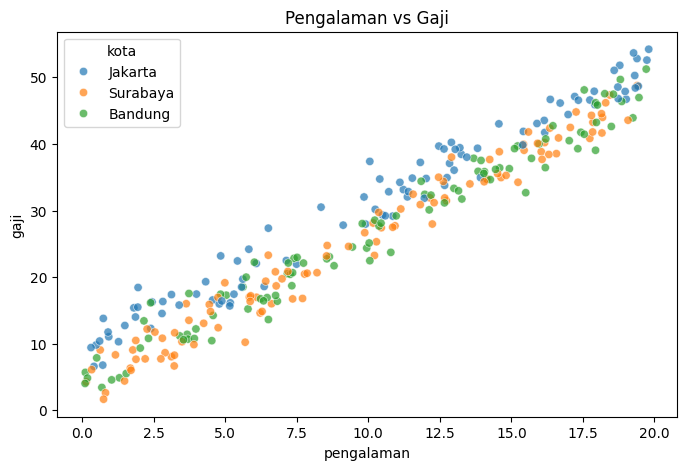

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # 0=SMA, 1=D3, 2=S1
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print("Shape Dataset:", df.shape)
print(df.head())

print("\nStatistik Deskriptif:")
print(df.describe().round(2))

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    alpha=0.7
)
plt.title('Pengalaman vs Gaji')
plt.show()


### Langkah 2: Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One Hot Encoding
df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print("Kolom setelah encoding:")
print(df.columns)

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train : {X_train.shape[0]} data")
print(f"Test  : {X_test.shape[0]} data")

# Scaling
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding:
Index(['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya'], dtype='object')
Train : 240 data
Test  : 60 data


### Langkah 3: Latih Model Regresi Linear

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

print(f"Intercept (β0): {model.intercept_:.3f}")

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
})

coef_df = coef_df.sort_values(
    by='Koefisien',
    ascending=False
)

print("\nKoefisien Model:")
print(coef_df)

Intercept (β0): 27.514

Koefisien Model:
           Fitur  Koefisien
0     pengalaman     13.042
2   kota_Jakarta      1.837
1            edu      1.188
3  kota_Surabaya     -0.292


### Interpretasi

* Koefisien positif → meningkatkan gaji.
* Koefisien negatif → menurunkan gaji.
* Fitur dengan koefisien terbesar merupakan faktor yang paling berpengaruh terhadap prediksi gaji.

## Langkah 4: Evaluasi Model


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("=== HASIL EVALUASI ===")
print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R²   = {r2:.4f}")
print(f"RMSE - MAE = {rmse - mae:.3f}")


=== HASIL EVALUASI ===
MAE  = 1.649
RMSE = 2.123
R²   = 0.9740
RMSE - MAE = 0.474


### Interpretasi

* MAE menunjukkan rata-rata kesalahan prediksi.
* RMSE memberikan penalti lebih besar untuk kesalahan besar.
* R² menunjukkan persentase variasi data yang berhasil dijelaskan model.
* Jika RMSE jauh lebih besar daripada MAE, kemungkinan terdapat outlier.

## Langkah 5: Visualisasi Hasil

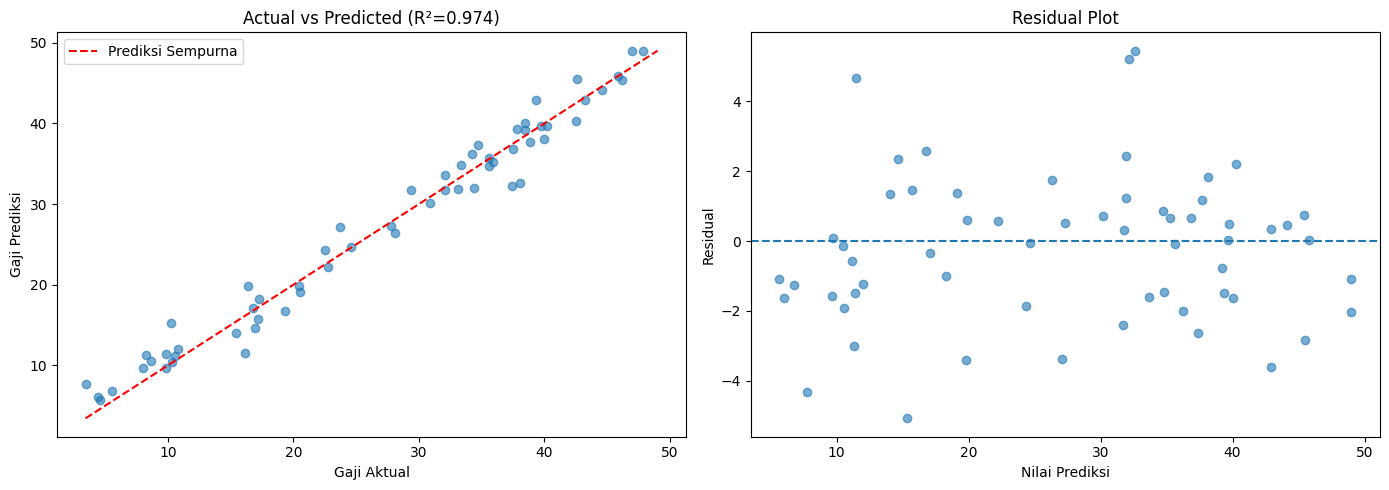

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.6
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--',
    label='Prediksi Sempurna'
)

axes[0].set_xlabel("Gaji Aktual")
axes[0].set_ylabel("Gaji Prediksi")
axes[0].set_title(f"Actual vs Predicted (R²={r2:.3f})")
axes[0].legend()

# Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.6
)

axes[1].axhline(
    0,
    linestyle='--'
)

axes[1].set_xlabel("Nilai Prediksi")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

## Kesimpulan

1. Dataset berhasil diproses menggunakan One-Hot Encoding dan StandardScaler.
2. Model Regresi Linear berhasil dilatih menggunakan data training.
3. Performa model dievaluasi menggunakan MAE, RMSE, dan R².
4. Visualisasi Actual vs Predicted menunjukkan kualitas prediksi model.
5. Residual Plot digunakan untuk memeriksa apakah asumsi regresi linear terpenuhi.